In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('Netflix_Customer _Subscription.csv')

print(df.head)

print(df.dtypes)


<bound method NDFrame.head of    Time Period  Subscribers
0   01-04-2013     34240000
1   01-07-2013     35640000
2   01-10-2013     38010000
3   01-01-2014     41430000
4   01-04-2014     46130000
5   01-07-2014     47990000
6   01-10-2014     50650000
7   01-01-2015     54480000
8   01-04-2015     59620000
9   01-07-2015     62080000
10  01-10-2015     66020000
11  01-01-2016     70840000
12  01-04-2016     77710000
13  01-07-2016     79900000
14  01-10-2016     83280000
15  01-01-2017     89090000
16  01-04-2017     94360000
17  01-07-2017     99040000
18  01-10-2017    104020000
19  01-01-2018    110640000
20  01-04-2018    118900000
21  01-07-2018    124350000
22  01-10-2018    130420000
23  01-01-2019    139260000
24  01-04-2019    148860000
25  01-07-2019    151560000
26  01-10-2019    158330000
27  01-01-2020    167090000
28  01-04-2020    182860000
29  01-07-2020    192950000
30  01-10-2020    195150000
31  01-01-2021    203660000
32  01-04-2021    207640000
33  01-07-2021    

In [2]:
# Convertir la columna 'Date' a tipo datetime
df['Time Period'] = pd.to_datetime(df['Time Period'], format='%d-%m-%Y', errors='coerce')
# agregar columnas de año mes y día
df['Año'] = df['Time Period'].dt.year
df['Mes'] = df['Time Period'].dt.month
df['Día'] = df['Time Period'].dt.day
df['Periodo'] = df['Time Period'].dt.to_period('M').astype(str).str.replace('-', '')
df['Nombre_Mes'] = df['Time Period'].dt.strftime('%B')

print(df.head())


  Time Period  Subscribers   Año  Mes  Día Periodo Nombre_Mes
0  2013-04-01     34240000  2013    4    1  201304      April
1  2013-07-01     35640000  2013    7    1  201307       July
2  2013-10-01     38010000  2013   10    1  201310    October
3  2014-01-01     41430000  2014    1    1  201401    January
4  2014-04-01     46130000  2014    4    1  201404      April


In [3]:
df_mensual=df.groupby('Año')['Subscribers'].sum().reset_index()

print(df_mensual.head())

    Año  Subscribers
0  2013    107890000
1  2014    186200000
2  2015    242200000
3  2016    311730000
4  2017    386510000


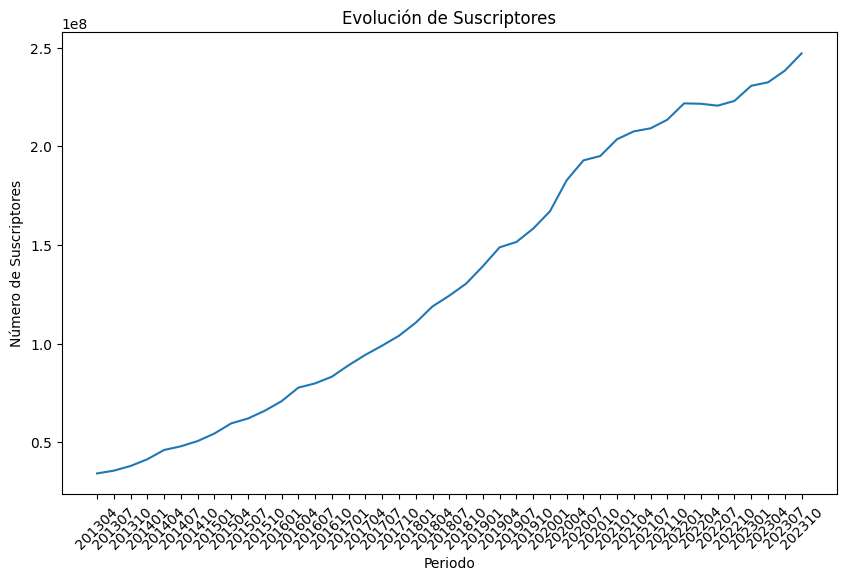

In [5]:

# Cargar el dataset
#df = pd.read_csv('Netflix_Customer _Subscription.csv')

# Visualizar la evolución de suscriptores
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Periodo', y='Subscribers')
plt.title('Evolución de Suscriptores')
plt.xlabel('Periodo')
plt.ylabel('Número de Suscriptores')
plt.xticks(rotation=45)

plt.show()

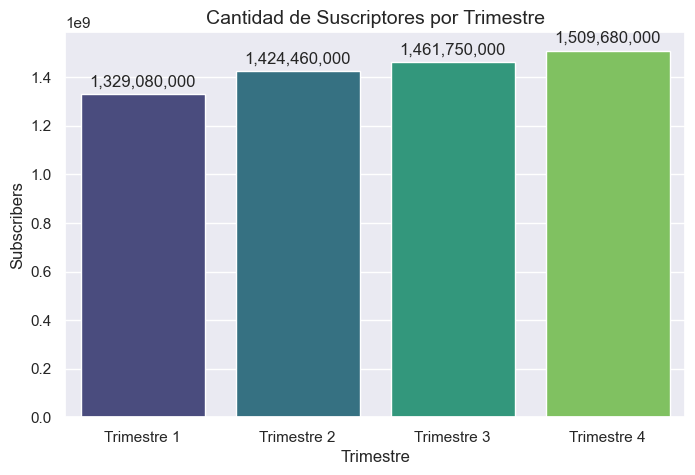

In [6]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Crear columna Trimestre
df['Trimestre'] = pd.to_datetime(df['Time Period']).dt.to_period('Q')

# Agrupar por Trimestre y calcular la suma de Suscriptores
df_trimestral = df.groupby(df['Trimestre'].dt.quarter)['Subscribers'].sum().reset_index()
df_trimestral.rename(columns={'Trimestre': 'Numero_Trimestre'}, inplace=True)
df_trimestral['Numero_Trimestre'] = 'Trimestre ' + df_trimestral['Numero_Trimestre'].astype(str)


# Configurar el estilo del gráfico
sns.set(style='darkgrid')
# Crear el gráfico de barras con el argumento `hue=x`
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Numero_Trimestre', y='Subscribers', hue='Numero_Trimestre', data=df_trimestral, palette='viridis',
legend=False)

# Agregar el valor a cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

# Configurar título y etiquetas
plt.title('Cantidad de Suscriptores por Trimestre', fontsize=14)
plt.xlabel('Trimestre', fontsize=12)
plt.ylabel('Subscribers', fontsize=12)

# Mostrar gráfico
plt.show()

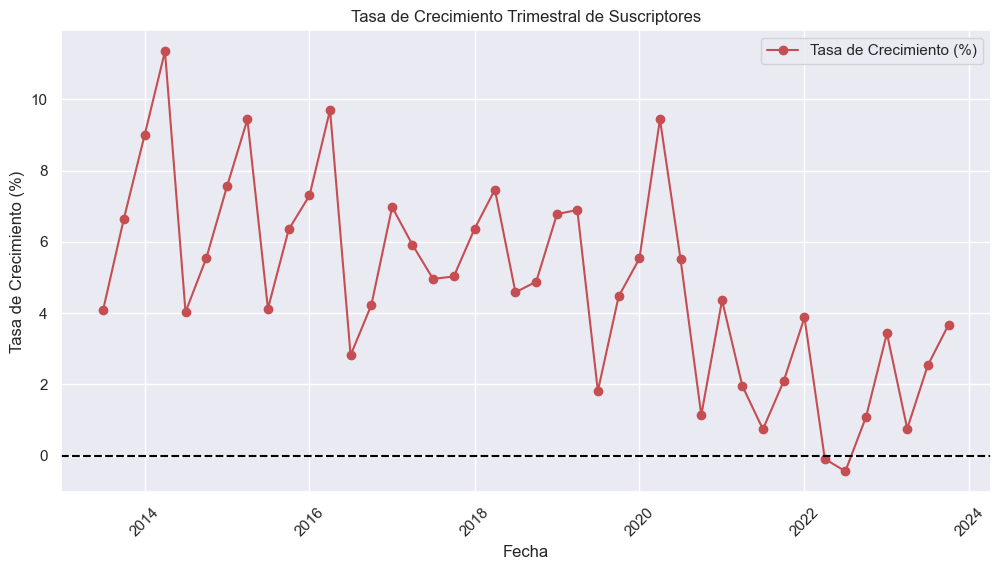

In [8]:

df["Fecha"] = pd.to_datetime(df["Time Period"])
#  Calcular la tasa de crecimiento trimestral
df["Tasa_Crecimiento"] = df["Subscribers"].pct_change() * 100

# Identificar los períodos de mayor caída
caidas_significativas = df[df["Tasa_Crecimiento"] < 0]

# Calcular el promedio de crecimiento anual
df["Año"] = df["Fecha"].dt.year
promedio_anual = df.groupby("Año")["Tasa_Crecimiento"].mean()

# Gráfico de líneas de tasa de crecimiento
plt.figure(figsize=(12, 6))
plt.plot(df["Fecha"], df["Tasa_Crecimiento"], marker='o', linestyle='-', color='r', label="Tasa de Crecimiento (%)")
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel("Fecha")
plt.ylabel("Tasa de Crecimiento (%)")
plt.title("Tasa de Crecimiento Trimestral de Suscriptores")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()



Promedio anual de crecimiento:
Año
2013    5.369308
2014    7.479243
2015    6.867284
2016    6.011797
2017    5.719958
2018    5.823721
2019    4.988086
2020    5.407212
2021    2.287636
2022    1.111497
2023    2.599993
Name: Tasa_Crecimiento, dtype: float64


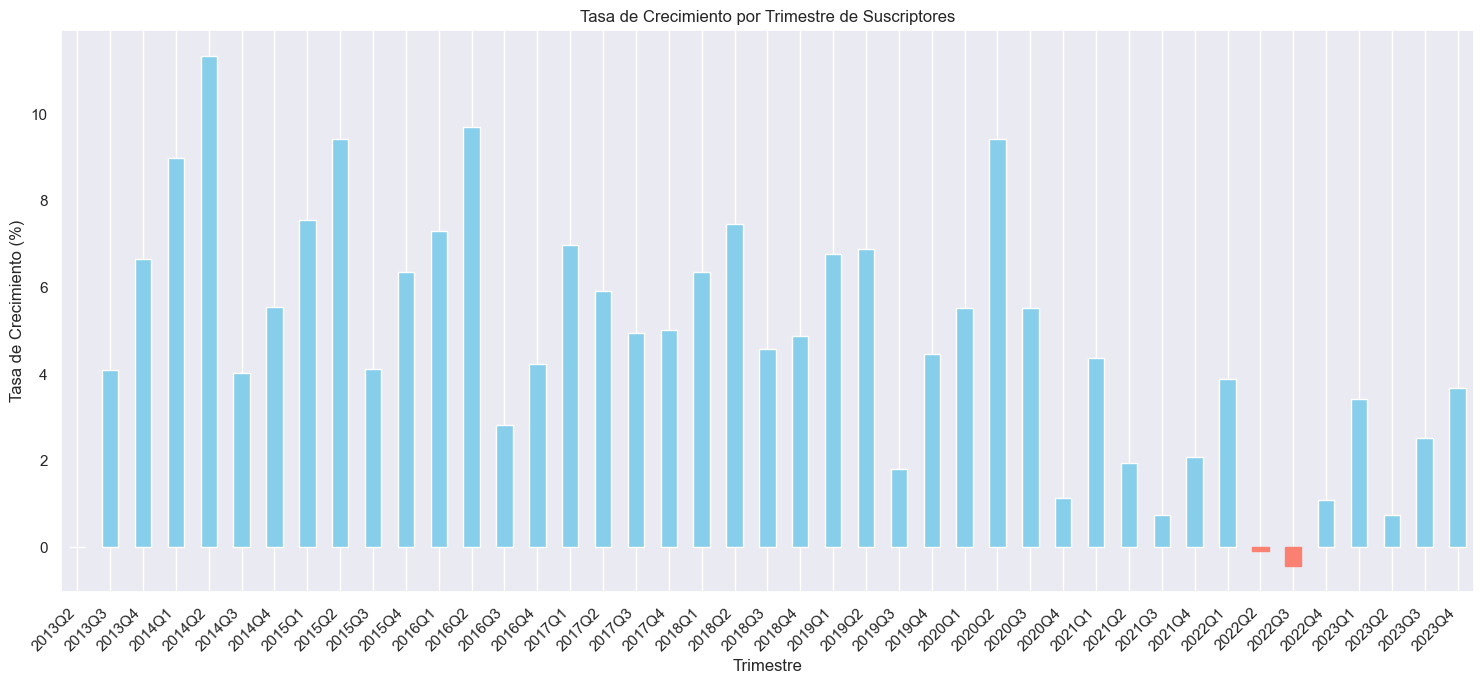

In [9]:


# Mostrar el promedio anual de crecimiento
print("Promedio anual de crecimiento:")
print(promedio_anual)

# Gráfico de barras de tasa de crecimiento por trimestre
df["Trimestre"] = df["Fecha"].dt.to_period("Q")
crecimiento_trimestral = df.groupby("Trimestre")["Tasa_Crecimiento"].sum() # o .mean() si prefieres el promedio

plt.figure(figsize=(15, 7))
ax = crecimiento_trimestral.plot(kind='bar', color='skyblue') # Store the axes object
for bar in ax.patches:
    if bar.get_height() < 0:
        bar.set_color('salmon') # Or any other color you prefer

plt.xlabel("Trimestre")
plt.ylabel("Tasa de Crecimiento (%)")
plt.title("Tasa de Crecimiento por Trimestre de Suscriptores")
plt.xticks(rotation=45, ha='right')
plt.tight_layout() # Ajusta el layout para que no se corten las etiquetas
plt.grid(axis='y')
plt.show()
